# FWC time series with SIC

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import time
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [3]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [4]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [5]:
# open runoff zarr store - [m s-1]
runoff_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/EXFroff_AVG_DAILY.ZARR/', s3_options)

In [6]:
runoff_da

<xarray.Dataset> Size: 40GB
Dimensions:    (time: 2581, j: 1080, i: 1800, nv: 2)
Coordinates:
    XC         (j, i) float32 8MB dask.array<chunksize=(270, 450), meta=np.ndarray>
    YC         (j, i) float32 8MB dask.array<chunksize=(270, 450), meta=np.ndarray>
  * i          (i) int32 7kB 0 1 2 3 4 5 6 ... 1794 1795 1796 1797 1798 1799
  * j          (j) int32 4kB 0 1 2 3 4 5 6 ... 1074 1075 1076 1077 1078 1079
  * time       (time) datetime64[ns] 21kB 2014-01-15T12:00:00 ... 2021-02-07T...
    time_bnds  (time, nv) datetime64[ns] 41kB dask.array<chunksize=(2581, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    EXFroff    (time, j, i) float64 40GB dask.array<chunksize=(1, 270, 450), meta=np.ndarray>
Attributes: (12/50)
    Conventions:               CF-1.8, ACDD-1.3
    acknowledgement:           This research was carried out by the Jet Propu...
    author:                    Mike Wood, Marie Zahn, and Ian Fenty
    cdm_data_type:             Grid
    comment:                   SASSIE llc1080 V1R1 fields are consolidated on...
    creator_email:             ecco-group@mit.edu
    ...                        ...
    standard_name_vocabulary:  NetCDF Climate and Forecast (CF) Metadata Conv...
    summary:                   This dataset provides data variable and geomet...
    time_coverage_end:         2021-02-08T00:00:00
    time_coverage_start:       2014-01-15T00:00:00
    title:                     SASSIE Ocean Model EXFroff Parameter for the L...
    uuid:                      85fdf69c-133f-11ef-a277-0604868e061f

In [7]:
# carve out beaufort region
runoff_da_beaufort = runoff_da.EXFroff.isel(i=slice(450,750),j=slice(110,390))

HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)
HH_land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(110,390))

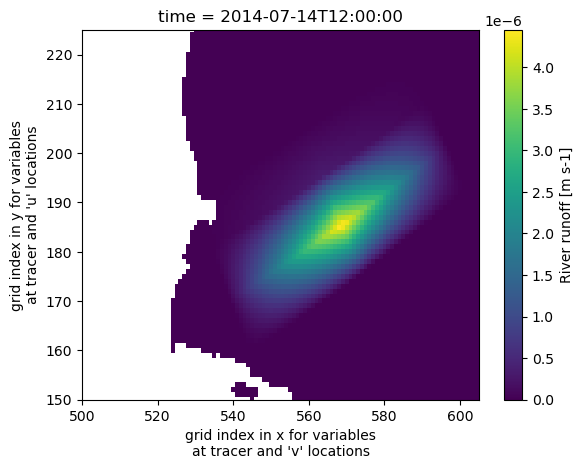

In [19]:
runoff_da_beaufort.isel(time=180).plot();
plt.xlim(500,605)
plt.ylim(150,225);

# Plot climatology

In [21]:
runoff_monthly = runoff_da_beaufort.groupby('time.month').mean(dim='time')

In [23]:
runoff_month_clim = runoff_monthly.sum(dim=['i','j'])

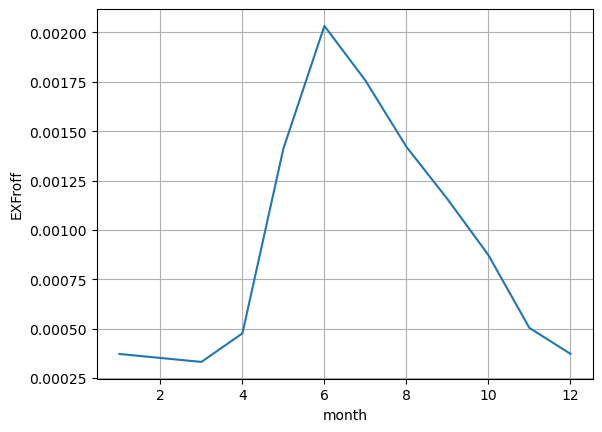

In [25]:
runoff_month_clim.plot()
plt.grid();

## Convert to cubic meters per second

In [28]:
beaufort_area = HH_grid.rAc.isel(i=slice(450,750),j=slice(110,390))

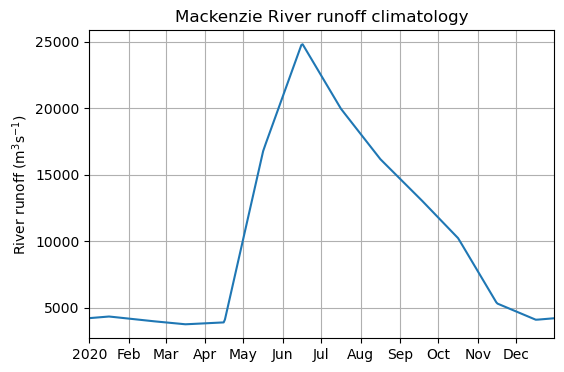

In [36]:
(runoff_da_beaufort.sel(time='2020')*beaufort_area).sum(dim=['i','j']).plot(figsize=[6,4])
plt.xlim([np.datetime64('2020-01-01'),np.datetime64('2020-12-31')])
plt.xlabel("")
plt.ylabel("River runoff (m$^3$s$^{-1}$)")
plt.title("Mackenzie River runoff climatology")
plt.grid();